In [28]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [29]:
#connect to sqlite database (creates a new file if it doesn't exist)?
conn = sqlite3.connect('sales_data.db')

# create a cursor to interact woth the database?
cursor = conn.cursor()


In [30]:
# create a sample table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY,
        product_name TEXT,
        quantity INTEGER,
        price REAL
    )
''')

In [31]:
# commit and close the connection?
conn.commit()

In [32]:
# sample data to insert
sales =[("Protein Bar",205,2.75),
       ("Omega-3",112,18.50),
       ("Fish Oil",	150,15.45),
       ("Biotin",168,12.30),
       ("Vitamin D3",185,20.50),
       ("Vitamin C",100,15.60),
       ("Glucosamine",101,21.15),
       ("Multivitamin",140,16.78),
       ("Probiotics",170,29.51),
       ("L-Carnitine",135,48.99),
       ("Collagen Powder",135,48.99),
       ("Yoga Mat",120,47.4),
      ("Vitamin B serum",100,28.30)]

In [33]:
# insert data into table
cursor.executemany('INSERT INTO sales (product_name, quantity, price) VALUES (?, ?, ?)', sales)

# commit changes
conn.commit()


In [34]:
#run a sql query to retrieve all sales data
query = "select * from sales"

# store query resuits in a pandas dataframe
df = pd.read_sql_query(query, conn)

In [35]:
# display the data
df.head()

,id,product_name,quantity,price
0,1,Protein Bar,205,2.75
1,2,Omega-3,112,18.50
2,3,Fish Oil,150,15.45
3,4,Biotin,168,12.30
4,5,Vitamin D3,185,20.50


In [38]:
query = '''
SELECT 
    product_name, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product_name
'''
x= pd.read_sql(query,conn)
x

,product_name,total_qty,revenue
0,Biotin,336,4132.8
1,Collagen Powder,270,13227.3
2,Fish Oil,300,4635.0
3,Glucosamine,202,4272.3
4,L-Carnitine,270,13227.3
5,Multivitamin,280,4698.4
6,Omega-3,224,4144.0
7,Probiotics,340,10033.4
8,Protein Bar,410,1127.5
9,Vitamin B serum,200,5660.0


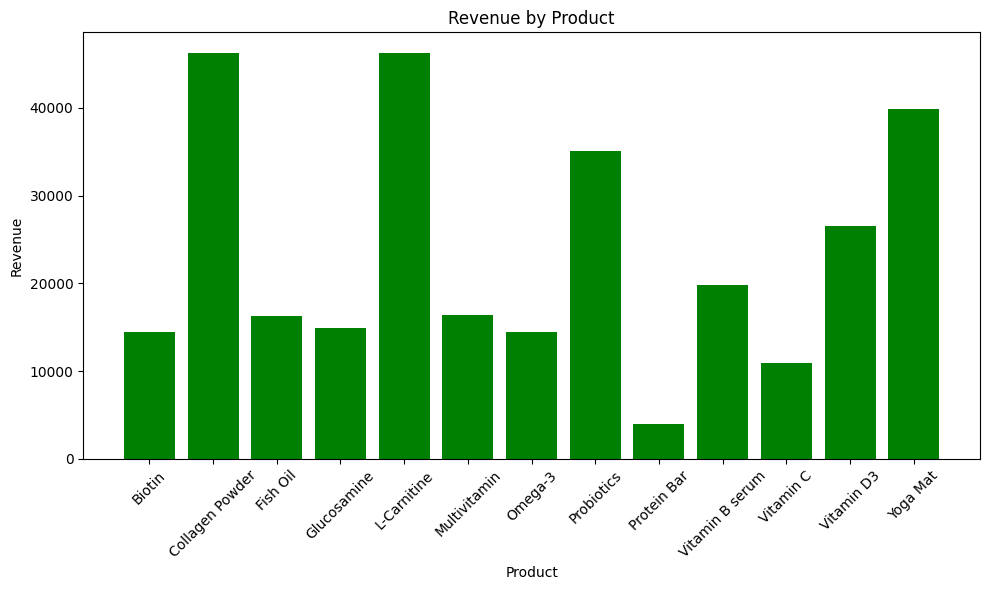

In [13]:
plt.figure(figsize=(10,6))
plt.bar(x["product_name"],x["revenue"],color="green")
plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
plt.savefig("sales_chart.png")

<Figure size 640x480 with 0 Axes>